# 日経平均株価 15分足

In [1]:
import sys

path_up = ".."
if not path_up in sys.path:
    sys.path.append(path_up)

In [2]:
import datetime

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import mplfinance as mpf
import numpy as np
import pandas as pd
import yfinance as yf

from funcs.commons import get_name_15min_chart, get_name_15min_chart_usd

In [3]:
code = "N225"
symbol = f"^{code}"
yticker = yf.Ticker(symbol)
df = yticker.history(period="1d", interval="15m")
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2026-07-22 09:00:00+09:00,66449.273438,67393.562500,66429.570312,67340.257812,0,0.0,0.0
2026-07-22 09:15:00+09:00,67358.828125,67511.281250,67164.226562,67488.117188,0,0.0,0.0
2026-07-22 09:30:00+09:00,67483.812500,67592.203125,67262.046875,67518.250000,0,0.0,0.0
2026-07-22 09:45:00+09:00,67516.890625,67531.757812,67144.398438,67365.187500,0,0.0,0.0
2026-07-22 10:00:00+09:00,67356.031250,67396.218750,67123.312500,67211.640625,0,0.0,0.0
2026-07-22 10:15:00+09:00,67218.101562,67528.851562,67218.101562,67415.203125,0,0.0,0.0
2026-07-22 10:30:00+09:00,67414.382812,67540.546875,67357.742188,67443.078125,0,0.0,0.0
2026-07-22 10:45:00+09:00,67446.648438,67578.828125,67425.781250,67520.710938,0,0.0,0.0
2026-07-22 11:00:00+09:00,67514.640625,67547.789062,67344.320312,67392.273438,0,0.0,0.0


In [4]:
dt_start = df.index[0]
dt_end = pd.to_datetime(
    f"{dt_start.year:04d}-{dt_start.month:02d}-{dt_start.day:02d} 15:30:00+09:00"
).tz_convert("Asia/Tokyo")
dt_start, dt_end

(Timestamp('2026-07-22 09:00:00+0900', tz='Asia/Tokyo'),
 Timestamp('2026-07-22 15:30:00+0900', tz='Asia/Tokyo'))

In [5]:
# 過去一週間のデータを取得
td = datetime.timedelta(days=7)
dt_first = df.index[0]
dt_prev = dt_first - td
df_last = yticker.history(interval="1d", start=str(dt_prev.date()))
print(df_last["Close"])
n = len(df_last)
lastclose = df_last[n - 2 : n - 1]["Close"].iloc[0]
#lastclose = 69317.50 # 6/15 終値
# 確認のため出力
df_last[n - 2 : n - 1]["Close"]

Date
2026-07-15 00:00:00+09:00    68751.507812
2026-07-16 00:00:00+09:00    66835.539062
2026-07-17 00:00:00+09:00    64141.121094
2026-07-21 00:00:00+09:00    66232.187500
2026-07-22 00:00:00+09:00    67511.117188
Name: Close, dtype: float64


Date
2026-07-21 00:00:00+09:00    66232.1875
Name: Close, dtype: float64

In [6]:
delta_open = df.head(1)["Open"].iloc[0] - lastclose
print(f"{delta_open:+.2f}")

+217.09


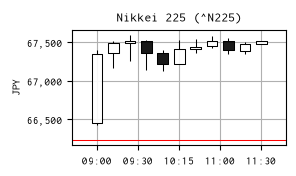

In [7]:
FONT_PATH = "../fonts/RictyDiminished-Regular.ttf"
fm.fontManager.addfont(FONT_PATH)

# FontPropertiesオブジェクト生成（名前の取得のため）
font_prop = fm.FontProperties(fname=FONT_PATH)
font_prop.get_name()

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["font.size"] = 8

fig, ax = plt.subplots(figsize=(3, 1.8))

ax.axhline(y=lastclose, color="red", linewidth=0.75)
mpf.plot(
    df,
    type="candle",
    style="default",
    datetime_format="%H:%M",
    xrotation=0,
    update_width_config=dict(candle_linewidth=0.75),
    ax=ax,
)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
ax.set_ylabel("JPY")
ax.grid()

if "shortName" in yticker.info:
    ax.set_title(f"{yticker.info['shortName']} ({symbol})")
elif "longName" in yticker.info:
    ax.set_title(f"{yticker.info['longName']} ({symbol})")
else:
    ax.set_title(f"{symbol}")

plt.tight_layout()
plt.savefig(get_name_15min_chart(code, dt_first))
plt.show()

In [8]:
code2 = "USDJPY=X"
symbol2 = code2
ticker2 = yf.Ticker(symbol2)

In [9]:
# 15分足で過去 2 日分のデータを取得
df_exchange = ticker2.history(period="2d", interval="15m")
df_exchange.index = df_exchange.index.tz_convert("Asia/Tokyo")
df_exchange

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2026-07-21 08:00:00+09:00,162.490997,162.509003,162.481995,162.503998,0,0.0,0.0
2026-07-21 08:15:00+09:00,162.494003,162.509003,162.483994,162.496994,0,0.0,0.0
2026-07-21 08:30:00+09:00,162.494003,162.507996,162.490005,162.492996,0,0.0,0.0
2026-07-21 08:45:00+09:00,162.492004,162.507004,162.479004,162.479996,0,0.0,0.0
2026-07-21 09:00:00+09:00,162.479996,162.494003,162.438004,162.479004,0,0.0,0.0
...,...,...,...,...,...,...,...
2026-07-22 11:00:00+09:00,163.143997,163.179993,163.141006,163.167999,0,0.0,0.0
2026-07-22 11:15:00+09:00,163.162003,163.169998,163.065994,163.091995,0,0.0,0.0
2026-07-22 11:30:00+09:00,163.091995,163.112000,163.078003,163.095001,0,0.0,0.0


In [10]:
ser_rate = df_exchange.loc[df.index, "Close"]
ser_rate
df2 = pd.DataFrame()
df2["Open"] = df["Open"] / ser_rate
df2["High"] = df["High"] / ser_rate
df2["Low"] = df["Low"] / ser_rate
df2["Close"] = df["Close"] / ser_rate
df2

,Open,High,Low,Close
Datetime,,,,
2026-07-22 09:00:00+09:00,407.391843,413.181156,407.271045,412.854352
2026-07-22 09:15:00+09:00,413.099869,414.034837,411.906412,413.892776
2026-07-22 09:30:00+09:00,413.721772,414.386281,412.362198,413.932898
2026-07-22 09:45:00+09:00,413.881433,413.972569,411.598040,412.951486
2026-07-22 10:00:00+09:00,412.872573,413.118910,411.446075,411.987501
2026-07-22 10:15:00+09:00,411.956400,413.860879,411.956400,413.164367
2026-07-22 10:30:00+09:00,413.144156,413.917343,412.797038,413.320013
2026-07-22 10:45:00+09:00,413.420412,414.230619,413.292504,413.874385
2026-07-22 11:00:00+09:00,413.773785,413.976940,412.729951,413.023839


In [11]:
dt = df_exchange.head(1).index[0]
dt_last_close = pd.to_datetime(f"{str(dt.date())} 15:15:00+09:00")
print(dt_last_close)
last_close_usd = df_exchange.loc[dt_last_close, "Close"]
last_close_usd

2026-07-21 15:15:00+09:00


np.float64(162.51800537109375)

前日終値（ドル換算） 407.5375362180047


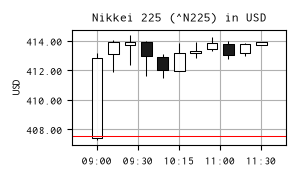

In [12]:
FONT_PATH = "../fonts/RictyDiminished-Regular.ttf"
fm.fontManager.addfont(FONT_PATH)

# FontPropertiesオブジェクト生成（名前の取得のため）
font_prop = fm.FontProperties(fname=FONT_PATH)
font_prop.get_name()

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["font.size"] = 8

fig, ax = plt.subplots(figsize=(3, 1.8))

ax.axhline(y=lastclose / last_close_usd, color="red", linewidth=0.75)
print("前日終値（ドル換算）", lastclose / last_close_usd)
mpf.plot(
    df2,
    type="candle",
    style="default",
    datetime_format="%H:%M",
    xrotation=0,
    update_width_config=dict(candle_linewidth=0.75),
    ax=ax,
)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
ax.set_ylabel("USD")
ax.grid()

if "shortName" in yticker.info:
    ax.set_title(f"{yticker.info['shortName']} ({symbol}) in USD")
elif "longName" in yticker.info:
    ax.set_title(f"{yticker.info['longName']} ({symbol}) in USD")
else:
    ax.set_title(f"{symbol}")

plt.tight_layout()
plt.savefig(get_name_15min_chart_usd(code, dt_first))
plt.show()